# Data Loading


SEEDING

In [1]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
DEVICE = torch.device("cpu")
from collections import defaultdict
def seed_everything(seed: int = 42):
    os.environ["PYTHONHASHSEED"] = str(seed)

    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    # Flower / Ray stability
    os.environ["RAY_DISABLE_IMPORT_WARNING"] = "1"

SEED = 42
seed_everything(SEED)


Data Path

In [2]:
DATA_PATH = "/content/drive/MyDrive/Dataset/final_feature_label_dataset_normalized_interpolated (1).xlsx"


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Data Ordering

In [4]:
df = pd.read_excel(DATA_PATH)

df = df.sort_values(
    by=["person", "session", "window_start"],
    ascending=True
).reset_index(drop=True)

print("Persons:", df.person.nunique())
print("Sessions:", df.session.nunique())
print("Total rows:", len(df))


Persons: 12
Sessions: 3
Total rows: 2819


Columns isolation

In [5]:
META_COLS = ["person", "session", "window_start"]
LABEL_COLS = ["physicalFatigueScore", "mentalFatigueScore"]


Feature cols

In [6]:
FEATURE_COLS = [
    "hr_mean", "hr_std",
    "duration_mean", "duration_std",
    "ax_mean", "ax_std",
    "ay_mean", "ay_std",
    "az_mean", "az_std",
    "eda_mean", "eda_std",
    "temp_mean", "temp_std"
]


Assertion

In [7]:
assert not any(c in FEATURE_COLS for c in META_COLS)
assert not any(c in FEATURE_COLS for c in LABEL_COLS)


In [8]:
X = df[FEATURE_COLS].values
y = df[LABEL_COLS].values

In [9]:
clients_raw = {}

for person_id, g in df.groupby("person", sort=False):
    clients_raw[person_id] = {
        "X": g[FEATURE_COLS].values.astype(np.float32),
        "y": g[LABEL_COLS].values.astype(np.float32)
    }

print("Federated clients:", len(clients_raw))


Federated clients: 12


In [10]:
def normalize_client(X, split_ratio=0.8):
    scaler = StandardScaler()

    split = int(len(X) * split_ratio)

    # Fit ONLY on earlier windows
    X_train = scaler.fit_transform(X[:split])
    X_test  = scaler.transform(X[split:])

    return X_train, X_test


In [11]:
class FatigueClientDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


Train Test Split

In [12]:
client_datasets = {}

for pid, data in clients_raw.items():
    X = data["X"]
    y = data["y"]

    X_train, X_test = normalize_client(X)
    split = int(len(y) * 0.8)

    y_train = y[:split]
    y_test  = y[split:]

    client_datasets[pid] = {
        "train": FatigueClientDataset(X_train, y_train),
        "test":  FatigueClientDataset(X_test, y_test)
    }


In [13]:
# ============================================================
# FIX: Define client ↔ person mapping for Flower
# ============================================================

PERSON_IDS = sorted(list(client_datasets.keys()))
NUM_CLIENTS = len(PERSON_IDS)

INPUT_DIM = len(FEATURE_COLS)

print("PERSON_IDS:", PERSON_IDS)
print("NUM_CLIENTS:", NUM_CLIENTS)
print("INPUT_DIM:", INPUT_DIM)


PERSON_IDS: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
NUM_CLIENTS: 12
INPUT_DIM: 14


# Model Definition



In [14]:
# ============================================================
# Linear
# ============================================================


class FatigueNet_Linear(nn.Module):
    def __init__(self, input_dim, out_dim=2):
        super().__init__()
        self.fc = nn.Linear(input_dim, out_dim)

    def forward(self, x):
        return self.fc(x)

# ============================================================
# MLP
# ============================================================


class FatigueNet_MLP(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, out_dim=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, out_dim)
        )

    def forward(self, x):
        return self.net(x)


# ============================================================
# Residual
# ============================================================

class FatigueNet_Residual(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, out_dim=2):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, hidden_dim)
        self.head = nn.Linear(hidden_dim, out_dim)
        self.act = nn.ReLU()

    def forward(self, x):
        h1 = self.act(self.fc1(x))
        h2 = self.act(self.fc2(h1)) + h1
        h3 = self.act(self.fc3(h2)) + h2
        return self.head(h3)

# ============================================================
# Dual
# ============================================================


class FatigueNet_Dual(nn.Module):
    def __init__(self, input_dim, hidden_dim=64):
        super().__init__()
        self.shared = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU()
        )
        self.physical = nn.Linear(hidden_dim, 1)
        self.mental = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        h = self.shared(x)
        return torch.cat([self.physical(h), self.mental(h)], dim=1)

# ============================================================
# TabNet
# ============================================================

class TabNetBlock(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.fc1 = nn.Linear(dim, dim * 2)
        self.fc2 = nn.Linear(dim * 2, dim)
        self.attention = nn.Sequential(
            nn.Linear(dim, dim),
            nn.Sigmoid()
        )
        self.norm = nn.LayerNorm(dim)

    def forward(self, x):
        attn = self.attention(x)
        h = F.gelu(self.fc1(x))
        h = self.fc2(h)
        return self.norm(attn * h + x)


class FatigueNet_TabNet(nn.Module):
    def __init__(self, input_dim, hidden_dim=64):
        super().__init__()
        self.embed = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU()
        )
        self.block1 = TabNetBlock(hidden_dim)
        self.block2 = TabNetBlock(hidden_dim)
        self.out = nn.Linear(hidden_dim, 2)

    def forward(self, x):
        h = self.embed(x)
        h = self.block1(h)
        h = self.block2(h)
        return self.out(h)


import torch
import torch.nn as nn
import torch.nn.functional as F


class SqueezeExcitation(nn.Module):
    def __init__(self, channels, reduction=4):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction),
            nn.ReLU(),
            nn.Linear(channels // reduction, channels),
            nn.Sigmoid()
        )

    def forward(self, x):
        weights = self.fc(x)
        return x * weights


class CrossFeatureAttention(nn.Module):
    def __init__(self, input_dim, embed_dim):
        super().__init__()
        self.input_dim = input_dim
        self.embed_dim = embed_dim

        self.feature_embeds = nn.ModuleList([
            nn.Linear(1, embed_dim) for _ in range(input_dim)
        ])

        self.cross_attn = nn.MultiheadAttention(embed_dim, num_heads=4, batch_first=True)
        self.norm = nn.LayerNorm(embed_dim)

    def forward(self, x):
        embedded = []
        for i, emb in enumerate(self.feature_embeds):
            feat = x[:, i:i+1]
            embedded.append(emb(feat))
        features = torch.stack(embedded, dim=1)

        attn_out, _ = self.cross_attn(features, features, features)
        return self.norm(attn_out + features)


class FeatureInteractionLayer(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.weight = nn.Parameter(torch.randn(input_dim, 1))
        self.bias = nn.Parameter(torch.zeros(input_dim))

    def forward(self, x0, x):
        xw = torch.matmul(x, self.weight)
        cross = x0 * xw + self.bias
        return cross + x

# ============================================================
# MSARNetv3
# ============================================================


class FatigueNet_MSARv3(nn.Module):
    def __init__(self, input_dim, embed_dim=32, num_heads=4):
        super().__init__()
        self.input_dim = input_dim
        self.embed_dim = embed_dim

        self.input_proj = nn.Sequential(
            nn.Linear(input_dim, input_dim * 2),
            nn.LayerNorm(input_dim * 2),
            nn.GELU()
        )

        self.cross_feat_attn = CrossFeatureAttention(input_dim, embed_dim)
        self.cross_proj = nn.Linear(input_dim * embed_dim, input_dim * 2)

        self.feat_interact1 = FeatureInteractionLayer(input_dim * 2)
        self.feat_interact2 = FeatureInteractionLayer(input_dim * 2)

        self.se_block = SqueezeExcitation(input_dim * 2, reduction=4)

        self.self_attn = nn.MultiheadAttention(input_dim * 2, num_heads, batch_first=True, dropout=0.1)
        self.attn_norm = nn.LayerNorm(input_dim * 2)

        self.deep_path = nn.Sequential(
            nn.Linear(input_dim * 2, input_dim * 4),
            nn.LayerNorm(input_dim * 4),
            nn.GELU(),
            nn.Dropout(0.15),
            nn.Linear(input_dim * 4, input_dim * 2),
            nn.LayerNorm(input_dim * 2),
            nn.GELU()
        )

        self.gate_net = nn.Sequential(
            nn.Linear(input_dim * 2, input_dim),
            nn.LayerNorm(input_dim),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(input_dim, 4)
        )
        self.gate_temperature = nn.Parameter(torch.ones(1))

        self.output_net = nn.Sequential(
            nn.Linear(input_dim * 2, 256),
            nn.LayerNorm(256),
            nn.GELU(),
            nn.Dropout(0.15),
            nn.Linear(256, 128),
            nn.LayerNorm(128),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(128, 64),
            nn.GELU(),
            nn.Linear(64, 2)
        )

        self._initialize_weights()

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight, gain=0.5)
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.LayerNorm):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        x_proj = self.input_proj(x)
        x0 = x_proj

        cross_feat = self.cross_feat_attn(x)
        cross_feat = cross_feat.reshape(cross_feat.size(0), -1)
        p1 = self.cross_proj(cross_feat)

        p2 = self.feat_interact1(x_proj, x_proj)
        p2 = self.feat_interact2(x_proj, p2)
        p2 = self.se_block(p2)

        p3 = x_proj.unsqueeze(1)
        p3, _ = self.self_attn(p3, p3, p3)
        p3 = p3.squeeze(1)
        p3 = self.attn_norm(p3 + x_proj)

        p4 = self.deep_path(x_proj)

        gates = self.gate_net(x_proj)
        gates = F.softmax(gates / self.gate_temperature, dim=-1)

        combined = (gates[:, 0:1] * p1 +
                   gates[:, 1:2] * p2 +
                   gates[:, 2:3] * p3 +
                   gates[:, 3:4] * p4)

        combined = combined + x0

        return self.output_net(combined)

# ============================================================
# DeepFM
# ============================================================

class FatigueNet_DeepFM(nn.Module):
    def __init__(self, input_dim, embedding_dim=32, hidden_dims=[128, 64], dropout=0.1, out_dim=2):
        super().__init__()
        self.input_dim = input_dim
        self.embedding_dim = embedding_dim

        self.feature_embeddings = nn.Parameter(torch.randn(input_dim, embedding_dim))

        self.linear = nn.Linear(input_dim, 1)

        deep_layers = []
        prev_dim = input_dim
        for hidden_dim in hidden_dims:
            deep_layers.extend([
                nn.Linear(prev_dim, hidden_dim),
                nn.BatchNorm1d(hidden_dim),
                nn.ReLU(),
                nn.Dropout(dropout)
            ])
            prev_dim = hidden_dim

        self.deep_network = nn.Sequential(*deep_layers)

        self.output_layer = nn.Linear(1 + 1 + hidden_dims[-1], out_dim)

    def forward(self, x):
        linear_out = self.linear(x)

        x_embeddings = x.unsqueeze(2) * self.feature_embeddings.unsqueeze(0)

        sum_of_embeddings = x_embeddings.sum(dim=1)
        sum_of_embeddings_squared = sum_of_embeddings ** 2

        squared_of_embeddings = x_embeddings ** 2
        squared_sum_of_embeddings = squared_of_embeddings.sum(dim=1)

        fm_out = 0.5 * (sum_of_embeddings_squared - squared_sum_of_embeddings).sum(dim=1, keepdim=True)

        deep_out = self.deep_network(x)

        combined = torch.cat([linear_out, fm_out, deep_out], dim=1)
        output = self.output_layer(combined)

        return output


# ============================================================
# AutoInt
# ============================================================

class FatigueNet_AutoInt(nn.Module):
    def __init__(self, input_dim, embedding_dim=64, num_heads=4, num_layers=3,
                 use_residual=True, dropout=0.1, out_dim=2):
        super().__init__()
        self.input_dim = input_dim
        self.embedding_dim = embedding_dim
        self.use_residual = use_residual

        self.embedding = nn.Linear(input_dim, input_dim * embedding_dim)

        self.attention_layers = nn.ModuleList([
            nn.MultiheadAttention(
                embedding_dim,
                num_heads,
                dropout=dropout,
                batch_first=True
            ) for _ in range(num_layers)
        ])

        self.layer_norms = nn.ModuleList([
            nn.LayerNorm(embedding_dim) for _ in range(num_layers)
        ])

        if use_residual:
            self.residual_layers = nn.ModuleList([
                nn.Linear(embedding_dim, embedding_dim) for _ in range(num_layers)
            ])

        self.output_layer = nn.Sequential(
            nn.Linear(input_dim * embedding_dim, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, out_dim)
        )

    def forward(self, x):
        batch_size = x.size(0)

        embedded = self.embedding(x)
        embedded = embedded.view(batch_size, self.input_dim, self.embedding_dim)

        attn_output = embedded
        for i, attn_layer in enumerate(self.attention_layers):
            residual = attn_output
            attn_out, _ = attn_layer(attn_output, attn_output, attn_output)

            attn_out = self.layer_norms[i](attn_out)

            if self.use_residual:
                attn_output = attn_out + self.residual_layers[i](residual)
            else:
                attn_output = attn_out

        output = attn_output.view(batch_size, -1)
        output = self.output_layer(output)

        return output

# ============================================================
# DCN2
# ============================================================

class CrossNetwork(nn.Module):
    def __init__(self, input_dim, num_layers=3):
        super().__init__()
        self.num_layers = num_layers

        self.weights = nn.ParameterList([
            nn.Parameter(torch.randn(input_dim, 1)) for _ in range(num_layers)
        ])
        self.biases = nn.ParameterList([
            nn.Parameter(torch.zeros(input_dim)) for _ in range(num_layers)
        ])

    def forward(self, x0):
        x = x0
        for i in range(self.num_layers):
            xw = torch.matmul(x, self.weights[i])
            cross = x0 * xw + self.biases[i]
            x = cross + x
        return x


class FatigueNet_DCNV2(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, cross_layers=3, deep_layers=3):
        super().__init__()

        self.input_norm = nn.LayerNorm(input_dim)
        self.cross_net = CrossNetwork(input_dim, num_layers=cross_layers)

        deep_layers_list = []
        in_dim = input_dim
        for _ in range(deep_layers):
            deep_layers_list.extend([
                nn.Linear(in_dim, hidden_dim),
                nn.ReLU(),
                nn.Dropout(0.1)
            ])
            in_dim = hidden_dim

        self.deep_net = nn.Sequential(*deep_layers_list)

        self.combination = nn.Linear(input_dim + hidden_dim, 64)
        self.output = nn.Linear(64, 2)

    def forward(self, x):
        x = self.input_norm(x)

        cross_out = self.cross_net(x)
        deep_out = self.deep_net(x)

        combined = torch.cat([cross_out, deep_out], dim=1)
        combined = F.relu(self.combination(combined))
        return self.output(combined)


# Centralised


In [15]:
# ============================================================
# CENTRALIZED DATASET (MERGED CLIENTS)
# ============================================================

all_train_X = []
all_train_y = []
all_test_X  = []
all_test_y  = []

for pid in PERSON_IDS:
    train_ds = client_datasets[pid]["train"]
    test_ds  = client_datasets[pid]["test"]

    all_train_X.append(train_ds.X.numpy())
    all_train_y.append(train_ds.y.numpy())

    all_test_X.append(test_ds.X.numpy())
    all_test_y.append(test_ds.y.numpy())

X_train_global = np.vstack(all_train_X)
y_train_global = np.vstack(all_train_y)

X_test_global  = np.vstack(all_test_X)
y_test_global  = np.vstack(all_test_y)

print("Global Train shape:", X_train_global.shape)
print("Global Test shape :", X_test_global.shape)

Global Train shape: (2250, 14)
Global Test shape : (569, 14)


In [16]:
class FatigueGlobalDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


train_loader_global = DataLoader(
    FatigueGlobalDataset(X_train_global, y_train_global),
    batch_size=32,
    shuffle=False
)

test_loader_global = DataLoader(
    FatigueGlobalDataset(X_test_global, y_test_global),
    batch_size=32,
    shuffle=False
)

## Train

In [17]:
def train_centralized_with_metrics(model, train_loader, test_loader, epochs=25, lr=1e-3):

    model.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    loss_history = []
    rmse_history = []
    mae_history = []
    r2_history = []

    for epoch in range(epochs):

        model.train()
        total_loss = 0.0

        for X, y in train_loader:
            X, y = X.to(DEVICE), y.to(DEVICE)

            optimizer.zero_grad()
            preds = model(X)
            loss = criterion(preds, y)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        loss_history.append(total_loss)

        # ---- Evaluate every epoch ----
        model.eval()
        y_true, y_pred = [], []

        with torch.no_grad():
            for X, y in test_loader:
                X = X.to(DEVICE)
                preds = model(X)

                y_true.append(y.numpy())
                y_pred.append(preds.cpu().numpy())

        y_true = np.vstack(y_true)
        y_pred = np.vstack(y_pred)

        mae = mean_absolute_error(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        r2 = r2_score(y_true, y_pred)

        rmse_history.append(rmse)
        mae_history.append(mae)
        r2_history.append(r2)

        print(f"Epoch {epoch+1}/{epochs} | Loss: {total_loss:.4f} | RMSE: {rmse:.4f}")

    return loss_history, rmse_history, mae_history, r2_history

## Evaluate

In [18]:
def evaluate_centralized(model, loader):

    model.eval()
    y_true, y_pred = [], []

    with torch.no_grad():
        for X, y in loader:
            X = X.to(DEVICE)
            preds = model(X)

            y_true.append(y.numpy())
            y_pred.append(preds.cpu().numpy())

    y_true = np.vstack(y_true)
    y_pred = np.vstack(y_pred)

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2_phys = r2_score(y_true[:, 0], y_pred[:, 0])
    r2_ment = r2_score(y_true[:, 1], y_pred[:, 1])

    print("\nMAE:", mae)
    print("RMSE:", rmse)
    print("R2 Physical:", r2_phys)
    print("R2 Mental:", r2_ment)

    return mae, rmse, r2_phys, r2_ment

## Run

In [19]:
# ============================================================
# CENTRALIZED HISTORY SAVER
# ============================================================

import os
import pandas as pd

BASE_DIR = "/content/drive/MyDrive/Fs/Centralized_Results_B_PF"
os.makedirs(BASE_DIR, exist_ok=True)


def save_centralized_history(model_name, rmse_history, mae_history, r2_history):

    rounds = list(range(1, len(rmse_history) + 1))

    df = pd.DataFrame({
        "round": rounds,
        "rmse": rmse_history,
        "mae": mae_history,
        "r2": r2_history
    })

    csv_path = os.path.join(BASE_DIR, f"{model_name}_Centralized.csv")
    df.to_csv(csv_path, index=False)

    print(f"✅ Saved → {csv_path}")

In [20]:
# ============================================================
# RUN CENTRALIZED TRAINING FOR ALL MODELS
# ============================================================

INPUT_DIM = X_train_global.shape[1]

models = {
    "Linear":        FatigueNet_Linear(INPUT_DIM),
    "MLP":           FatigueNet_MLP(INPUT_DIM),
    "Residual":      FatigueNet_Residual(INPUT_DIM),
    "Dual":          FatigueNet_Dual(INPUT_DIM),
    "MSARv3":         FatigueNet_MSARv3(INPUT_DIM),
    "DeepFM":         FatigueNet_DeepFM(INPUT_DIM),
    "AutoInt":        FatigueNet_AutoInt(INPUT_DIM),
    "TabNet":         FatigueNet_TabNet(INPUT_DIM),
    "DCNv2":          FatigueNet_DCNV2(INPUT_DIM),
}


for name, model in models.items():

    print(f"\n========== Training {name} ==========")

    # ---- Train model ----
    loss_history, rmse_history, mae_history, r2_history = \
        train_centralized_with_metrics(
            model,
            train_loader_global,
            test_loader_global,
            epochs=25,
            lr=1e-3
        )

    # ---- Save FL-style history ----
    save_centralized_history(
        model_name=name,
        rmse_history=rmse_history,
        mae_history=mae_history,
        r2_history=r2_history
    )

    # ---- Final evaluation print ----
    evaluate_centralized(model, test_loader_global)


========== Training Linear ==========
Epoch 1/25 | Loss: 34.8248 | RMSE: 1.6814
Epoch 2/25 | Loss: 25.9651 | RMSE: 1.4123
Epoch 3/25 | Loss: 19.7327 | RMSE: 1.1890
Epoch 4/25 | Loss: 15.2822 | RMSE: 1.0067
Epoch 5/25 | Loss: 12.0703 | RMSE: 0.8590
Epoch 6/25 | Loss: 9.7301 | RMSE: 0.7398
Epoch 7/25 | Loss: 8.0120 | RMSE: 0.6444
Epoch 8/25 | Loss: 6.7442 | RMSE: 0.5693
Epoch 9/25 | Loss: 5.8066 | RMSE: 0.5117
Epoch 10/25 | Loss: 5.1136 | RMSE: 0.4692
Epoch 11/25 | Loss: 4.6030 | RMSE: 0.4393
Epoch 12/25 | Loss: 4.2285 | RMSE: 0.4197
Epoch 13/25 | Loss: 3.9556 | RMSE: 0.4080
Epoch 14/25 | Loss: 3.7581 | RMSE: 0.4021
Epoch 15/25 | Loss: 3.6162 | RMSE: 0.4001
Epoch 16/25 | Loss: 3.5150 | RMSE: 0.4006
Epoch 17/25 | Loss: 3.4434 | RMSE: 0.4026
Epoch 18/25 | Loss: 3.3930 | RMSE: 0.4054
Epoch 19/25 | Loss: 3.3577 | RMSE: 0.4085
Epoch 20/25 | Loss: 3.3333 | RMSE: 0.4117
Epoch 21/25 | Loss: 3.3165 | RMSE: 0.4148
Epoch 22/25 | Loss: 3.3051 | RMSE: 0.4177
Epoch 23/25 | Loss: 3.2974 | RMSE: 0.4202

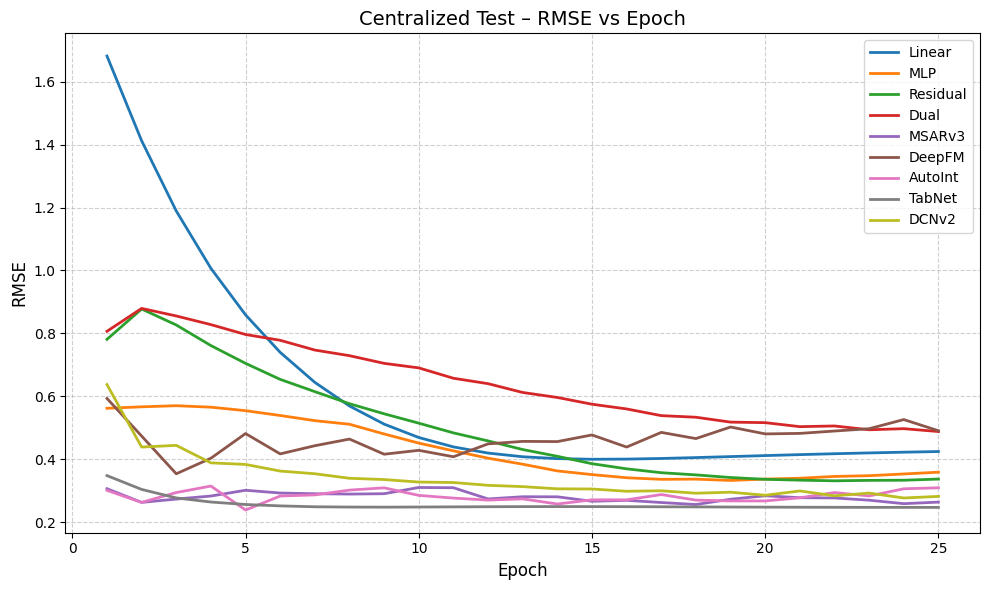

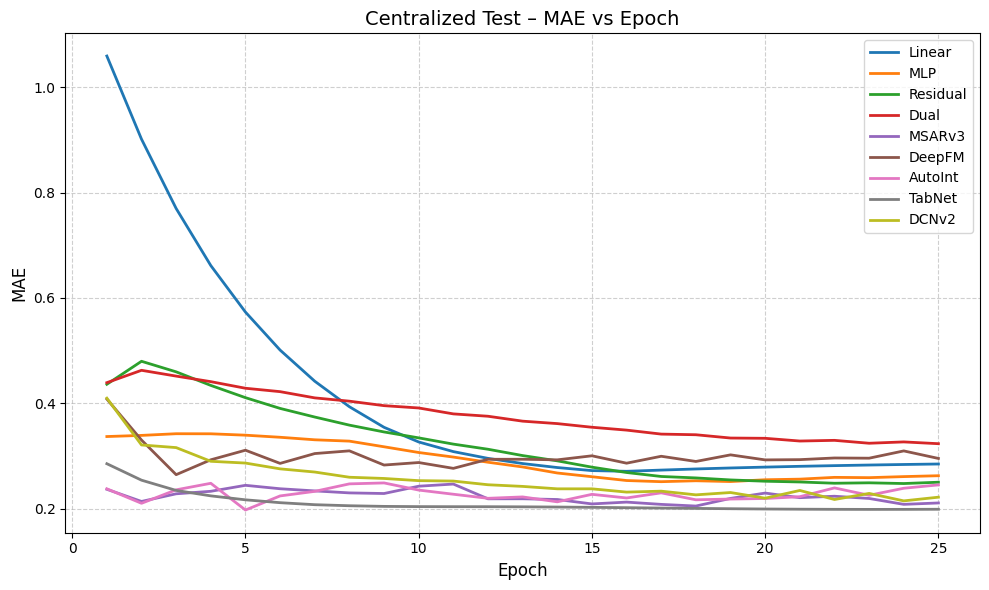

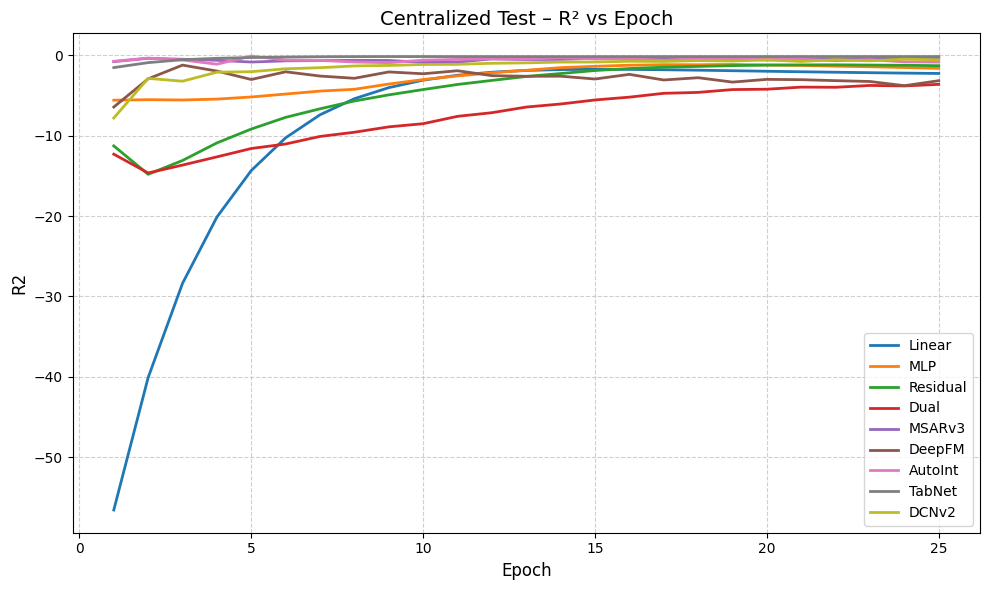

In [21]:
import os
import pandas as pd
import matplotlib.pyplot as plt

BASE_DIR = "/content/drive/MyDrive/Fs/Centralized_Results_B_PF"

# ---- List of models to compare ----
model_names = [
    "Linear",
    "MLP",
    "Residual",
    "Dual",
    "MSARv3",
    "DeepFM",
    "AutoInt",
    "TabNet",
    "DCNv2",
]


def plot_metric(metric_name, title):

    plt.figure(figsize=(10, 6))

    for model_name in model_names:

        csv_path = os.path.join(BASE_DIR, f"{model_name}_Centralized.csv")

        if not os.path.exists(csv_path):
            print(f"⚠ Missing file for {model_name}")
            continue

        df = pd.read_csv(csv_path)

        plt.plot(
            df["round"],
            df[metric_name],
            linewidth=2,
            label=model_name
        )

    plt.xlabel("Epoch", fontsize=12)
    plt.ylabel(metric_name.upper(), fontsize=12)
    plt.title(title, fontsize=14)
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.show()


# ---- Generate Plots ----
plot_metric("rmse", "Centralized Test – RMSE vs Epoch")
plot_metric("mae", "Centralized Test – MAE vs Epoch")
plot_metric("r2", "Centralized Test – R² vs Epoch")


In [22]:
import os
import pandas as pd

BASE_DIR = "/content/drive/MyDrive/Fs/Centralized_Results_B_PF"
OUTPUT_PATH = os.path.join(BASE_DIR, "All_Centralized_Combined.csv")

model_names = [
    "Linear",
    "MLP",
    "Residual",
    "Dual",
    "MSARv3",
    "DeepFM",
    "AutoInt",
    "TabNet",
    "DCNv2",
]

all_dfs = []

for model_name in model_names:

    csv_path = os.path.join(BASE_DIR, f"{model_name}_Centralized.csv")

    if not os.path.exists(csv_path):
        print(f"⚠ Missing file for {model_name}")
        continue

    df = pd.read_csv(csv_path)

    # Add model column
    df["model"] = model_name

    # Ensure correct column ordering
    df = df[["round", "model", "rmse", "mae", "r2"]]

    all_dfs.append(df)

# Combine everything
combined_df = pd.concat(all_dfs, ignore_index=True)

# Save
combined_df.to_csv(OUTPUT_PATH, index=False)

print(f"✅ Combined CSV saved at: {OUTPUT_PATH}")
print(f"Total rows: {len(combined_df)}")

✅ Combined CSV saved at: /content/drive/MyDrive/Fs/Centralized_Results_B_PF/All_Centralized_Combined.csv
Total rows: 225
